In [1]:
import os 
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

# modelos 
import statsmodels.api as sm 
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

In [2]:
data_path = os.path.join("..", "data", 'processed', 'dados_modelagem.csv')
df = pd.read_csv(data_path)
df['data'] = pd.to_datetime(df['data'], errors='coerce')
df = df.set_index('data')

# Definiçao da Volatidade

In [3]:
# desvio padrao do retorno-log dado lag 
ret = np.log(df['Close_PETR4.SA'])/df['Close_PETR4.SA'].shift(1)
df['sigma'] = ret.rolling(3).std().shift(-3)

<Axes: title={'center': 'volatidade - Close_PETR4.SA'}, xlabel='data'>

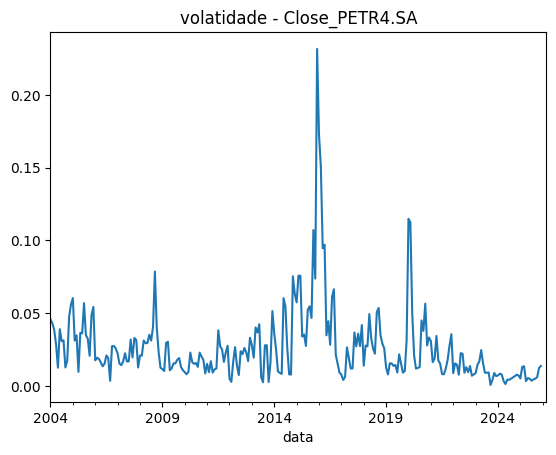

In [4]:
plt.title("volatidade - Close_PETR4.SA")
df['sigma'].plot()

In [5]:
# excluindo os preços para evitar vazamento
df = df.drop('Close_PETR4.SA', axis=1)

In [6]:
df_train = df.loc['2004-01-01':'2024-06-01'] # inicio de 2004 ate o primeiro semestre de 2021 
df_test = df.loc['2024-07-01':'2026-03-01'] # ate março de 2026 

In [7]:
print("dimensoes dos dados")
print("==="*50)
print()
print(f"Dados de treino: linhas -> {df_train.shape[0]} | colunas -> {df_train.shape[1]} | inicio: {df_train.reset_index()['data'].min()} -> final:{df_train.reset_index()['data'].max()}")
print()
print(f"Dados de teste: linhas -> {df_test.shape[0]} | colunas -> {df_test.shape[1]} | inicio: {df_test.reset_index()['data'].min()} -> final:{df_test.reset_index()['data'].max()}")
print()
print("==="*50)

dimensoes dos dados

Dados de treino: linhas -> 246 | colunas -> 14 | inicio: 2004-01-01 00:00:00 -> final:2024-06-01 00:00:00

Dados de teste: linhas -> 21 | colunas -> 14 | inicio: 2024-07-01 00:00:00 -> final:2026-03-01 00:00:00



In [8]:
models = {
    "Arvore_de_decisao": DecisionTreeRegressor(random_state=42), 
    "Gradient_Boosting":GradientBoostingRegressor(random_state=42), 
    "XGBoost": XGBRegressor(),
    "AdaBoost": AdaBoostRegressor(random_state=42)
    
}

In [9]:
# separaçao de x e y (treino)
X_train = df_train.drop('sigma', axis=1)
y_train = df_train['sigma']

In [10]:
# x e y (teste)
X_test = df_test.drop('sigma', axis=1)
y_test = df_test['sigma']
y_test = y_test.fillna(y_test.mean())

# VIF

In [11]:
vif_data = pd.DataFrame()
vif_data['Feature'] = X_train.columns
vif_data['VIF'] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
vif_data.sort_values(by='VIF', ascending=False)

,Feature,VIF
8,IBC-Br,697.875457
0,Produção de derivados de petróleo,336.631716
6,Producao Industrial,246.635954
1,Consumo de derivados de petróleo - gasolina,97.275567
10,Close_IBOV,75.149755
4,Cambio - IPCA,39.649489
2,Consumo de derivados de petróleo - Óleo combus...,26.576391
3,Selic,20.340282
11,BETA,17.514606
12,regime,4.574901


# Correlaçao das variaveis com o target

In [12]:
corr = df_train.corr()['sigma']
corr

Produção de derivados de petróleo                     -0.087036
Consumo de derivados de petróleo - gasolina            0.039992
Consumo de derivados de petróleo - Óleo combustível    0.147874
Selic                                                  0.122404
Cambio - IPCA                                          0.128564
IPCA                                                   0.230599
Producao Industrial                                   -0.142197
Balança comercial                                     -0.133180
IBC-Br                                                -0.074723
Volume_PETR4.SA                                       -0.011317
Close_IBOV                                            -0.259438
BETA                                                   0.353605
regime                                                 0.247813
sigma                                                  1.000000
Name: sigma, dtype: float64

# Treinamento 

In [13]:
# funçao para metricas
def metrics(y_true:pd.Series, y_pred:pd.Series) -> pd.DataFrame:
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    metrics_dict = {
        "MAE": mae, 
        "MSE": mse, 
        "R2": r2
    }
    return pd.DataFrame([metrics_dict])

Modelo Arvore_de_decisao

 metricas Treino ->    MAE  MSE   R2
0  0.0  0.0  1.0
 metricas Teste ->        MAE       MSE        R2
0  0.00364  0.000026 -1.591757


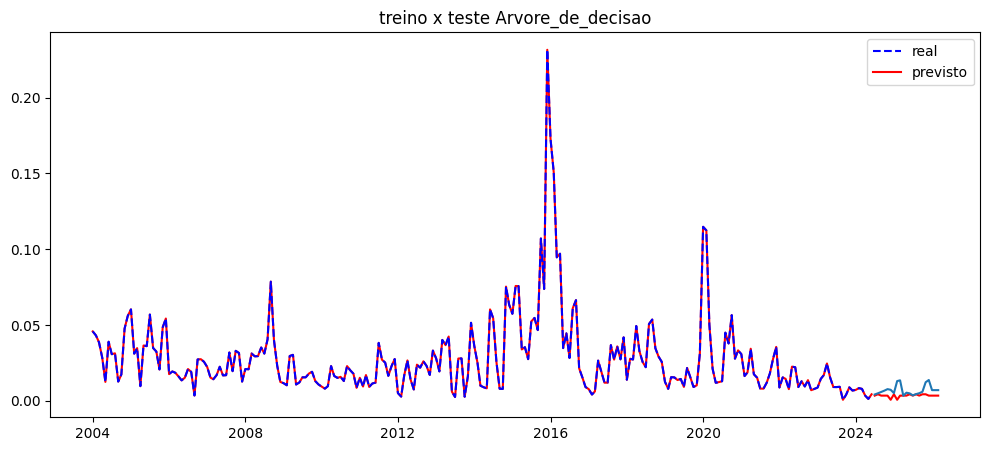

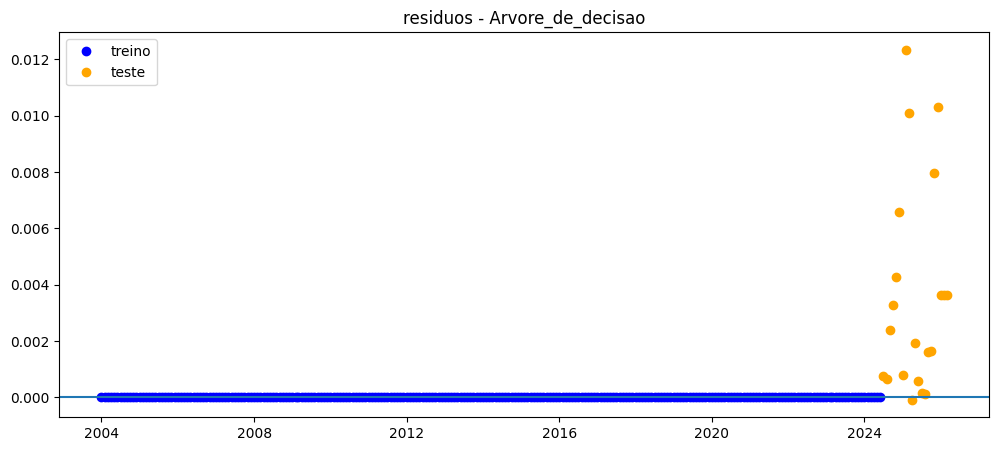

Modelo Gradient_Boosting

 metricas Treino ->         MAE       MSE        R2
0  0.004396  0.000031  0.956353
 metricas Teste ->         MAE       MSE        R2
0  0.005434  0.000044 -3.355137


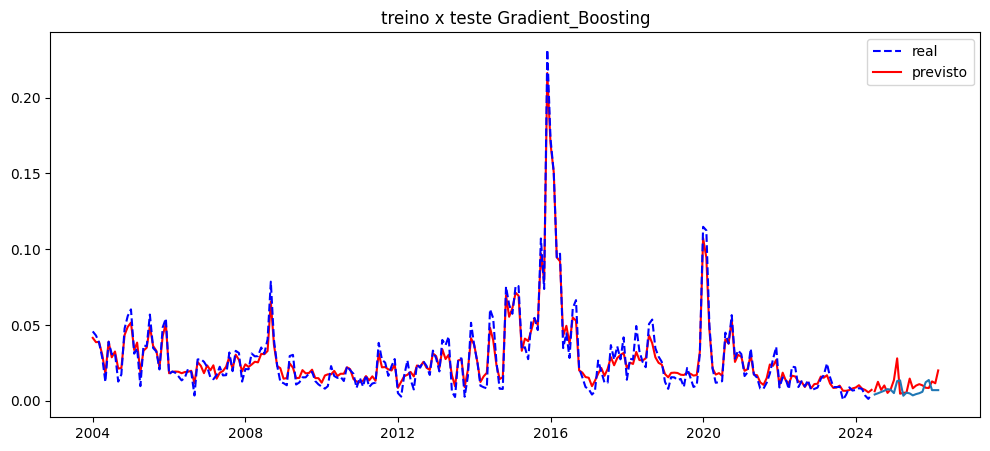

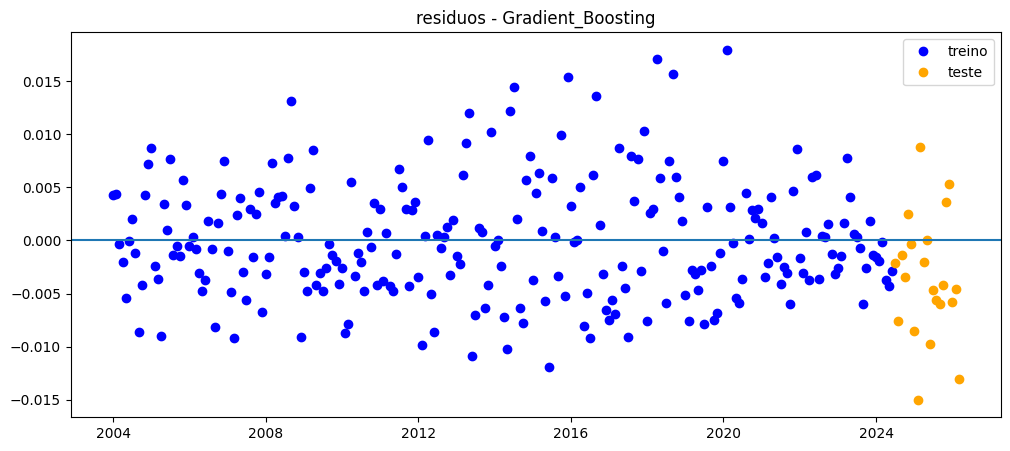

Modelo XGBoost

 metricas Treino ->        MAE           MSE        R2
0  0.00053  5.273374e-07  0.999248
 metricas Teste ->         MAE       MSE       R2
0  0.003608  0.000021 -1.09359


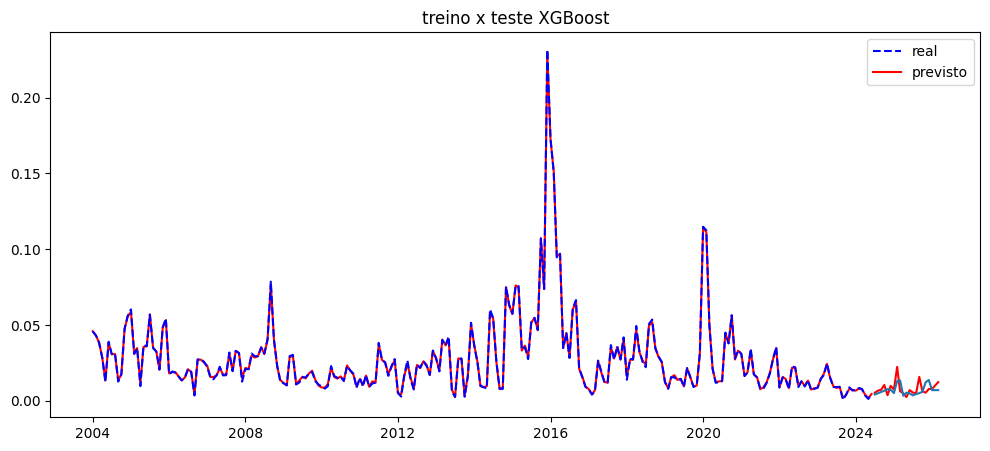

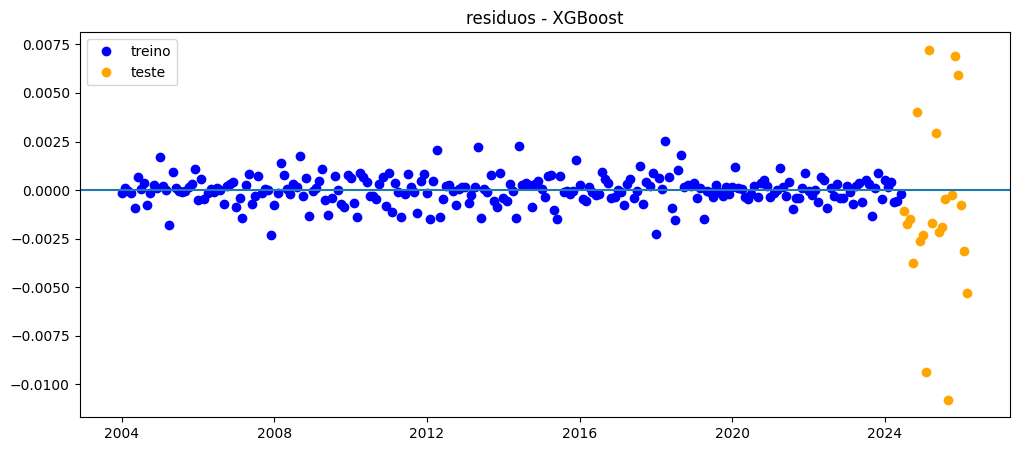

Modelo AdaBoost

 metricas Treino ->         MAE       MSE        R2
0  0.010797  0.000162  0.769196
 metricas Teste ->         MAE       MSE        R2
0  0.015533  0.000254 -24.00698


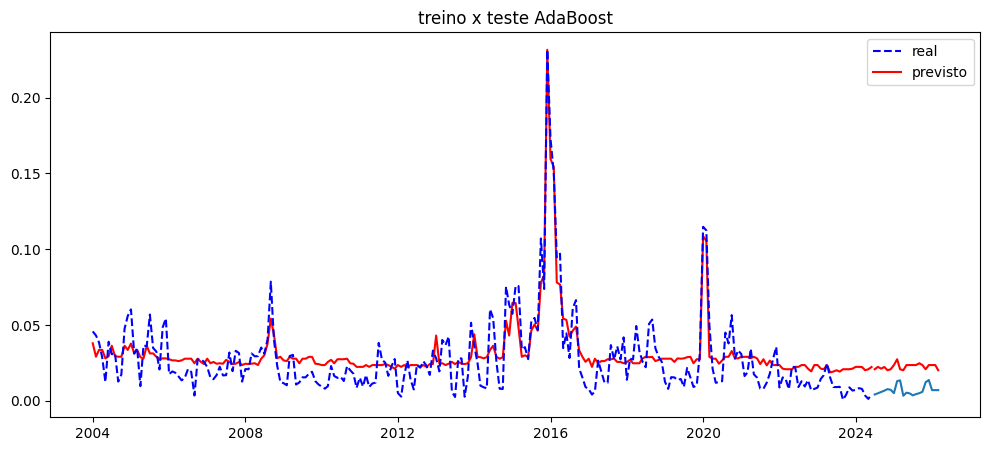

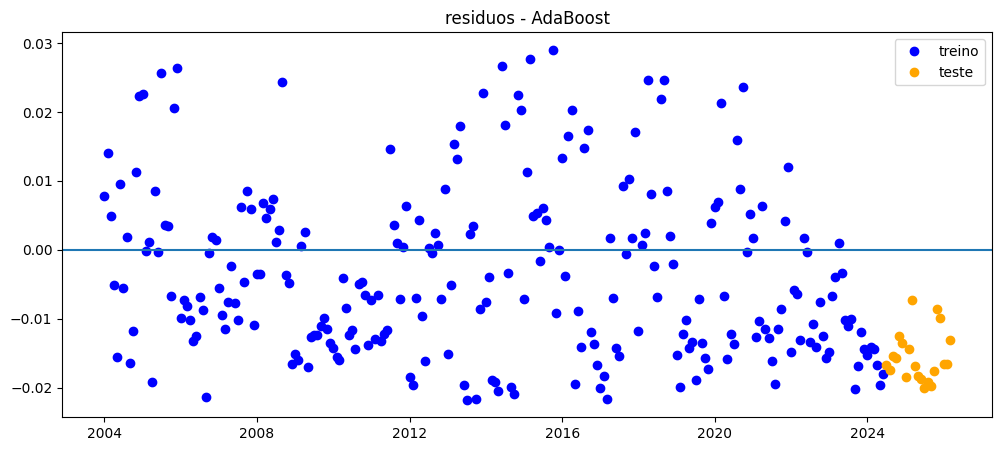

In [31]:
for i, model in models.items():
    model_ = model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    print("==="*20)
    print(f"Modelo {i}")
    print()
    print(f" metricas Treino -> {metrics(y_train, y_pred_train)}")
    print(f" metricas Teste -> {metrics(y_test, y_pred_test)}")
    
    plt.figure(figsize=(12,5))
    plt.title(f'treino x teste {i}')
    plt.plot(y_train.index, y_pred_train, color='red')
    plt.plot(y_train, linestyle='--', color='blue', label='real')
    plt.plot(y_test.index, y_pred_test, color='red', label='previsto')
    plt.plot(y_test)
    plt.legend()
    plt.show()
    
    # calculando residuo 
    resid_train = y_train - y_pred_train
    resid_test = y_test - y_pred_test
    plt.figure(figsize=(12,5))
    plt.title(f'residuos - {i}')
    plt.plot(resid_train, linestyle='none', marker='o', color='blue', label='treino')
    plt.plot(resid_test, linestyle='none', marker='o', color='orange', label='teste')
    plt.axhline(y=0)        
    plt.legend()
    plt.show()